In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel("C:\\Users\\siddh\\Downloads\\sample_ltv_dataset.xlsx")
df['order_date'] = pd.to_datetime(df['order_date'])
reference_date = df['order_date'].max()

In [5]:
recency = df.groupby('customer_id')['order_date'].max().reset_index()
recency['recency'] = (reference_date - recency['order_date']).dt.days

In [6]:
frequency = df.groupby('customer_id')['order_id'].count().reset_index()
frequency.columns = ['customer_id', 'frequency']

In [7]:
monetary = df.groupby('customer_id')['order_amount'].sum().reset_index()
monetary.columns = ['customer_id', 'monetary'

In [9]:
aov = df.groupby('customer_id')['order_amount'].mean().reset_index()
aov.columns = ['customer_id', 'aov']

In [11]:
features = recency[['customer_id', 'recency']]
features = features.merge(frequency, on='customer_id')
features = features.merge(monetary, on='customer_id')
features = features.merge(aov, on='customer_id')
features['ltv'] = features['monetary']
X = features[['recency', 'frequency', 'aov']]
y = features['ltv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1467.9208299999996
RMSE: 1687.6371510959254


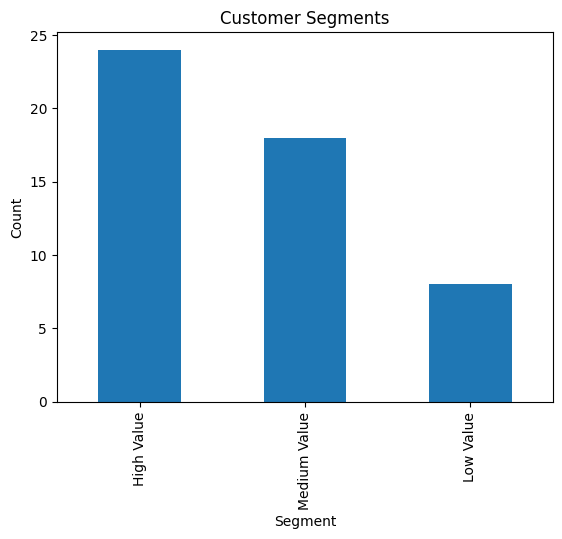

In [14]:
features['predicted_ltv'] = model.predict(X)
def segment(ltv):
    if ltv > 15000:
        return "High Value"
    elif ltv > 7000:
        return "Medium Value"
    else:
        return "Low Value"
features['segment'] = features['predicted_ltv'].apply(segment)
features.to_csv("ltv_predictions.csv", index=False)
plt.figure()
features['segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()